In [ ]:
!pip install networkx matplotlib

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    previous = {node: None for node in graph}

    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

In [ ]:
# The get_path function has been moved to the cell dUgiHvZS1LKD to ensure it is defined before use.

In [ ]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Menggunakan circular layout
    pos = nx.circular_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2000,
        font_weight='bold',
        arrows=True
    )

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            edge_color='red',
            width=3
        )

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

In [ ]:
def get_path(previous, target):
    path = []

    while target is not None:
        path.insert(0, target)
        target = previous[target]

    return path

# Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'A': 3, 'D': 8, 'E': 10},  # Siklus C -> A
    'D': {'E': 2, 'Z': 6},
    'E': {'B': 2, 'Z': 3, 'F': 1},   # Siklus E -> B
    'F': {'Z': 1},                   # Simpul baru
    'Z': {}
}

# Jalankan algoritma Dijkstra
start_node = 'A'
end_node = 'Z'

distances, previous = dijkstra_with_paths(graph, start_node)

# Ambil jalur terpendek
shortest_path = get_path(previous, end_node)

# Output hasil
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur Terpendek: {' -> '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

Jarak dari A ke Z: 13
Jalur Terpendek: A -> B -> D -> E -> F -> Z


NameError: name 'visualize_graph' is not defined

Jarak dari A ke Z: 13
Jalur Terpendek: A -> B -> D -> E -> F -> Z


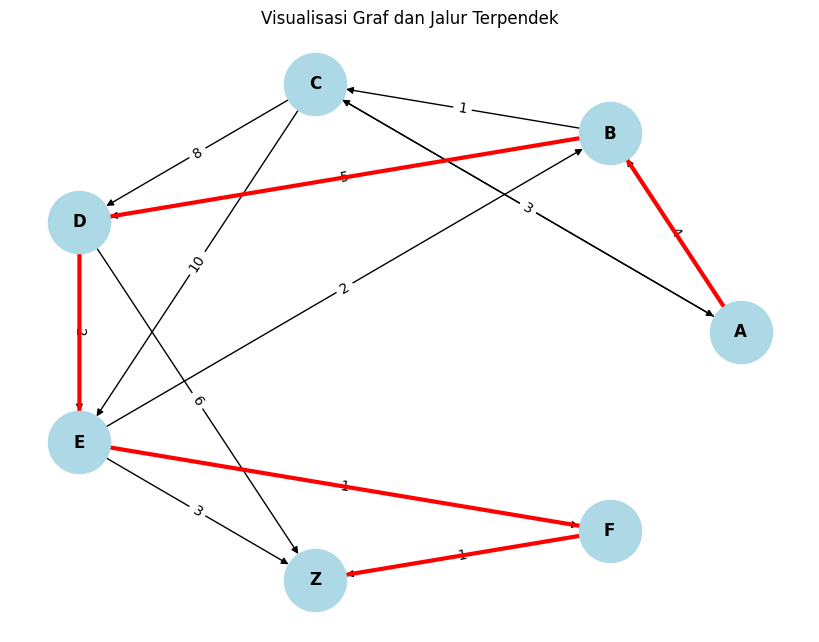

In [ ]:
The functions `dijkstra_with_paths`, `get_path`, `visualize_graph` and the graph definition with its execution have been consolidated and updated in previous cells for clarity and to avoid redundancy.

Jarak terpendek dari A ke Z = 7
Rute: A -> B -> G -> Z


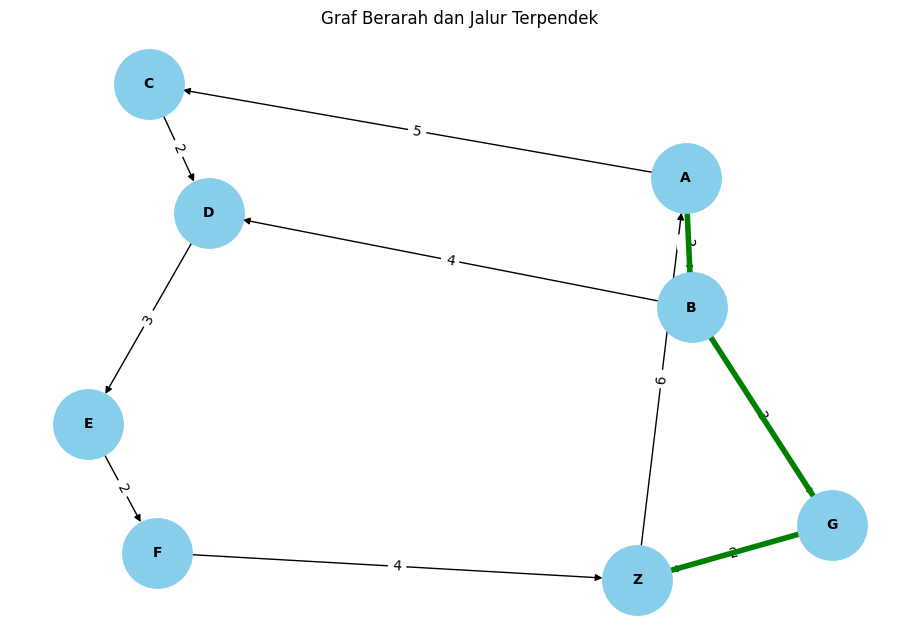

In [1]:
# Visualisasi Graf dan Pencarian Jalur Terpendek dengan Dijkstra
# pip install networkx matplotlib

import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra(graph, source):
    jarak = {node: float('inf') for node in graph}
    jarak[source] = 0

    parent = {node: None for node in graph}
    pq = [(0, source)]

    while pq:
        current_dist, current_node = heapq.heappop(pq)

        if current_dist > jarak[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            new_dist = current_dist + weight

            if new_dist < jarak[neighbor]:
                jarak[neighbor] = new_dist
                parent[neighbor] = current_node
                heapq.heappush(pq, (new_dist, neighbor))

    return jarak, parent

def shortest_path(parent, destination):
    hasil = []

    while destination:
        hasil.append(destination)
        destination = parent[destination]

    return hasil[::-1]

def draw_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Menggunakan layout berbeda
    pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(9, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2500,
        node_color="skyblue",
        font_size=10,
        font_weight="bold",
        arrows=True
    )

    labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    # Menyoroti jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            edge_color="green",
            width=4
        )

    plt.title("Graf Berarah dan Jalur Terpendek")
    plt.axis("off")
    plt.show()


# Graf dengan siklus dan simpul tambahan
graph = {
    'A': {'B': 2, 'C': 5},
    'B': {'D': 4, 'G': 3},
    'C': {'D': 2},
    'D': {'E': 3},
    'E': {'F': 2},
    'F': {'Z': 4},
    'G': {'Z': 2},
    'Z': {'A': 6}   # Membentuk siklus
}

start = 'A'
tujuan = 'Z'

jarak, parent = dijkstra(graph, start)

rute = shortest_path(parent, tujuan)

print("Jarak terpendek dari", start, "ke", tujuan, "=", jarak[tujuan])
print("Rute:", " -> ".join(rute))

draw_graph(graph, rute)